### 1. Carga datos

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data_sample/NASDAQ100_Historical_Data_reduced.csv.gz")
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400
...,...,...,...,...,...,...,...,...
514070,ZS,2026-02-11,175.62,175.87,165.36,171.00,171.00,2670100
514071,ZS,2026-02-12,171.99,173.99,163.00,170.90,170.90,2499300
514072,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
514073,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100


In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,514075.000000,514075.000000,514075.000000,514075.000000,514075.000000,5.140750e+05
mean,100.179428,101.486198,98.834356,100.186068,94.683734,2.596485e+07
std,241.284690,244.184916,238.271945,241.291633,239.893928,1.087908e+08
min,0.030000,0.030000,0.030000,0.030000,0.030000,0.000000e+00
25%,17.990000,18.270000,17.700000,17.990000,13.800000,1.653700e+06
50%,40.770000,41.320000,40.240000,40.800000,32.760000,3.758500e+06
75%,96.820000,98.040000,95.580000,96.850000,89.660000,1.056520e+07
max,5815.000000,5839.410000,5707.930000,5815.920000,5794.840000,9.230856e+09


### 2. Problema de Machine Learning

#### 2.1 Suficiencia de datos
El dataset contiene 510.000 filas y 8 columnas, una cantidad amplia y adecuada para entrenar modelos de Machine Learning sin problemas de escasez de datos.


#### 2.2 Formato y calidad inicial
Los datos vienen en un archivo CSV, un formato manejable y estándar.
Aparece un aviso de pandas indicando que algunas columnas tienen tipos mezclados, pero esto es habitual y puede corregirse durante el preprocesado.


#### 2.3 Relevancia de las variables
El dataset incluye información útil para modelar dirección de precios, como:
- Date
- Open
- High
- Low
- Close
- Adj. Close
- Volume
Estas variables permiten construir un modelo predictivo con sentido.


#### 2.4 Justificación del uso de Machine Learning
El comportamiento del Nasdaq‑100 es complejo y no lineal, por lo que métodos simples no capturan bien sus patrones. Las variables históricas del precio y del volumen contienen información útil que un modelo puede aprender para anticipar movimientos futuros. El machine learning permite detectar relaciones temporales, tendencias y señales que no son evidentes a simple vista. Además, ofrece métricas objetivas para evaluar la capacidad predictiva del modelo. En conjunto, es una herramienta adecuada para analizar y predecir la evolución del índice.


#### 2.5 Variable objetivo
En el dataset NASDAQ100_Historical_Data.csv, la variable objetivo más adecuada es el precio de cierre del día siguiente (Close en t+1).



### 3. dividir train y test

In [5]:
# Convertir la fecha a formato datetime
df["Date"] = pd.to_datetime(df["Date"])

# Ordenar por fecha (muy importante en series temporales)
df = df.sort_values("Date")

# Definir proporción de entrenamiento
train_size = int(len(df) * 0.8)

# Dividir en train y test respetando el tiempo
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Tamaño train:", train.shape)
print("Tamaño test:", test.shape)


Tamaño train: (411260, 8)
Tamaño test: (102815, 8)


### 4. Target

In [6]:
# Crear la variable objetivo: precio de cierre del día siguiente
df["Target"] = df["Close"].shift(-1)

# Eliminar la última fila (no tiene valor futuro)
df = df.dropna(subset=["Target"])


### 5. Comprension de variables

In [7]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
Index: 514074 entries, 0 to 470776
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Ticker     514074 non-null  object        
 1   Date       514074 non-null  datetime64[ns]
 2   Open       514074 non-null  float64       
 3   High       514074 non-null  float64       
 4   Low        514074 non-null  float64       
 5   Close      514074 non-null  float64       
 6   Adj Close  514074 non-null  float64       
 7   Volume     514074 non-null  int64         
 8   Target     514074 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 39.2+ MB


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target
count,514074,514074,514074.000000,514074.000000,514074.000000,514074.000000,514074.000000,5.140740e+05,514074.000000
unique,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2014-06-03 07:40:46.709228800,100.179297,101.486059,98.834228,100.185928,94.683583,2.596489e+07,100.186261
min,NaN,2000-01-03 00:00:00,0.030000,0.030000,0.030000,0.030000,0.030000,0.000000e+00,0.030000
25%,NaN,2008-04-30 00:00:00,17.990000,18.270000,17.700000,17.990000,13.800000,1.653700e+06,17.992500
50%,NaN,2015-01-16 00:00:00,40.770000,41.320000,40.240000,40.800000,32.760000,3.758500e+06,40.800000
75%,NaN,2020-12-07 00:00:00,96.820000,98.040000,95.580000,96.850000,89.660000,1.056520e+07,96.850000
max,NaN,2026-02-18 00:00:00,5815.000000,5839.410000,5707.930000,5815.920000,5794.840000,9.230856e+09,5815.920000


#### 5.1 Variables categóricas
No tiene variables categóricas

#### 5.2 Variables numéricas
El dataset está compuesto principalmente por variables numéricas que describen el comportamiento diario del índice Nasdaq‑100. Estas variables representan información cuantitativa esencial para analizar la evolución del mercado y construir un modelo predictivo:
- Open: precio al inicio de la sesión. Refleja las expectativas iniciales del mercado y sirve como referencia para medir movimientos intradía.
- High: precio máximo alcanzado durante el día. Indica presión compradora y amplitud del movimiento.
- Low: precio mínimo del día. Muestra momentos de venta intensa o correcciones.
- Close: precio de cierre, considerado el valor más representativo de la jornada. Suele utilizarse como variable objetivo en modelos de predicción.
- Adj Close: precio ajustado por dividendos y splits. Es útil para análisis a largo plazo, ya que elimina distorsiones.
- Volume: número total de operaciones realizadas. Permite identificar días de alta actividad, cambios de tendencia o confirmación de movimientos.
Estas variables pueden requerir escalado y permiten generar indicadores derivados como retornos, medias móviles o volatilidad.




#### 5.3 Variables temporales
El dataset incluye una variable temporal fundamental:
- Date: fecha de la sesión bursátil. Permite ordenar la serie temporal y extraer características como año, mes, día de la semana o patrones estacionales. Estas transformaciones ayudan a capturar tendencias y ciclos del mercado.


#### 5.4 Variables derivadas (a crear)
Aunque el dataset original no incluye variables categóricas o adicionales, es habitual generar nuevas características que mejoran la capacidad predictiva del modelo:
- Retornos diarios: miden la variación porcentual entre días consecutivos.
- Medias móviles: capturan tendencias de corto, medio y largo plazo.
- Volatilidad: refleja la variación del precio en ventanas temporales.
- Lags: valores rezagados de Close, Volume u otras columnas, necesarios para modelos supervisados basados en series temporales.
Estas variables enriquecen el dataset y permiten que el modelo aprenda patrones más complejos del comportamiento del índice.


### 6. Feat. Red. Preliminar

In [8]:
# --- 6. Feat. Red. Preliminar ---

# 1. Revisar NaNs por columna
na_counts = df.isna().sum()
na_percent = (df.isna().mean() * 100).round(2)

print("NaNs por columna:")
display(na_counts)

print("\nPorcentaje de NaNs:")
display(na_percent)

NaNs por columna:


Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64


Porcentaje de NaNs:


Ticker       0.0
Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
Target       0.0
dtype: float64

este dataset no tiene variables categoricas por lo que no hay cardinalidad alta entre ellas

### 7. Análisis univariante

In [9]:
# Seleccionar solo columnas numéricas para evitar errores en la correlación
df_num = df.select_dtypes(include=["float64", "int64"])
df_num.head()


,Open,High,Low,Close,Adj Close,Volume,Target
0,0.94,1.00,0.91,1.00,0.84,535796800,0.10
356203,0.10,0.10,0.09,0.10,0.09,300912000,0.49
366681,0.47,0.49,0.47,0.49,0.47,88847,4.47
60441,4.07,4.48,3.95,4.47,4.47,322352000,0.72
379740,0.74,0.74,0.67,0.72,0.72,3720000,62.94


In [10]:
# Distribución básica de cada variable numérica
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,514074.0,1.001793e+02,2.412849e+02,0.03,1.799000e+01,40.77,96.82,5.815000e+03
High,514074.0,1.014861e+02,2.441851e+02,0.03,1.827000e+01,41.32,98.04,5.839410e+03
Low,514074.0,9.883423e+01,2.382722e+02,0.03,1.770000e+01,40.24,95.58,5.707930e+03
Close,514074.0,1.001859e+02,2.412918e+02,0.03,1.799000e+01,40.80,96.85,5.815920e+03
Adj Close,514074.0,9.468358e+01,2.398941e+02,0.03,1.380000e+01,32.76,89.66,5.794840e+03
Volume,514074.0,2.596489e+07,1.087909e+08,0.00,1.653700e+06,3758500.00,10565200.00,9.230856e+09
Target,514074.0,1.001863e+02,2.412918e+02,0.03,1.799250e+01,40.80,96.85,5.815920e+03


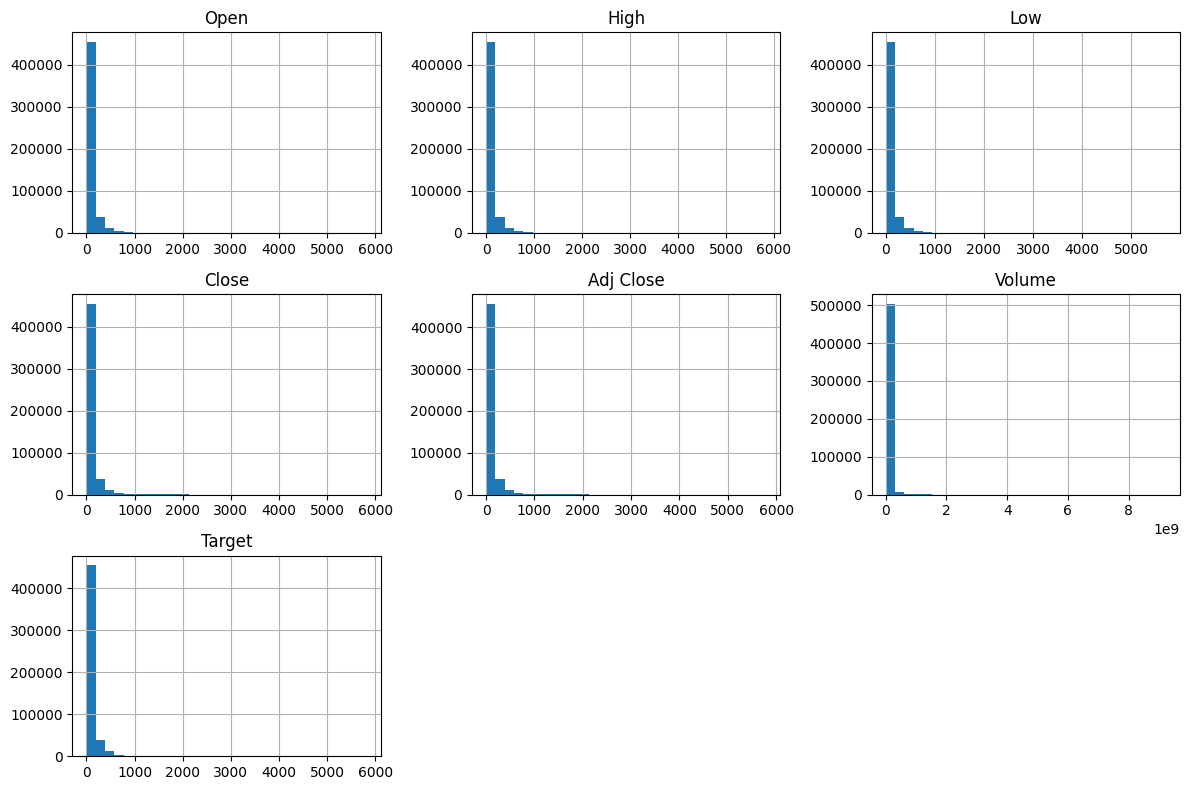

In [11]:
# Histograma de cada variable numérica
import matplotlib.pyplot as plt

df_num.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

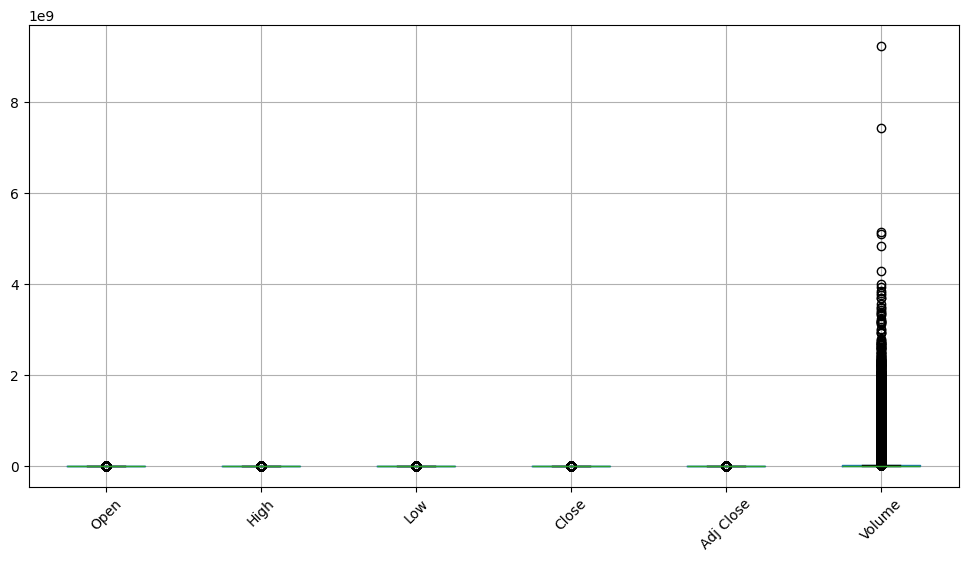

In [12]:
# Boxplots para detectar outliers
plt.figure(figsize=(12, 6))
df_num[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].boxplot()
plt.xticks(rotation=45)
plt.show()

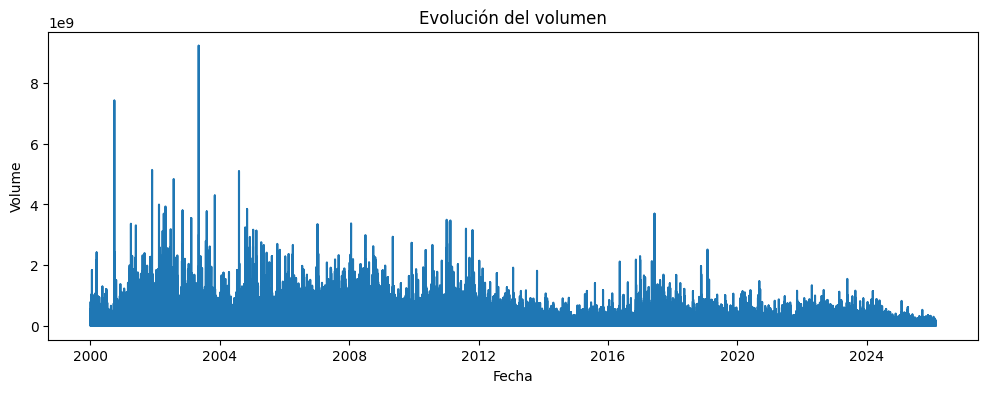

In [13]:
# Distribución temporal del volumen
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df_num["Volume"])
plt.title("Evolución del volumen")
plt.xlabel("Fecha")
plt.ylabel("Volume")
plt.show()

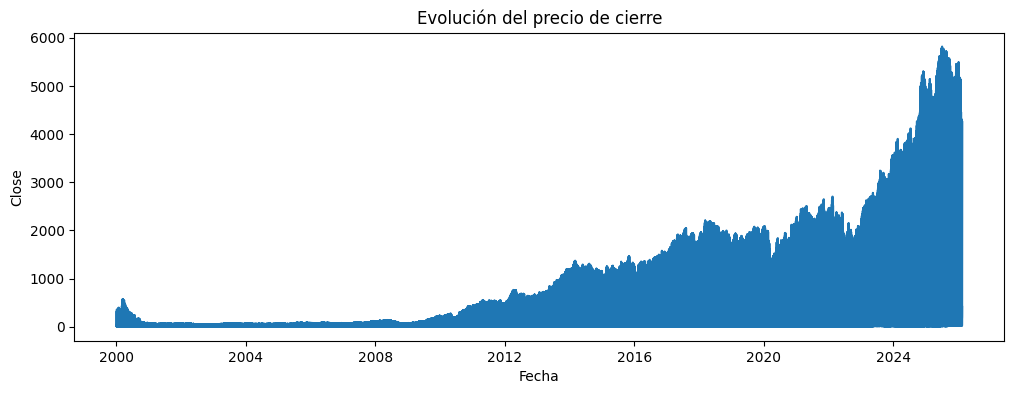

In [14]:
# Distribución temporal del precio de cierre
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Close"])
plt.title("Evolución del precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.show()

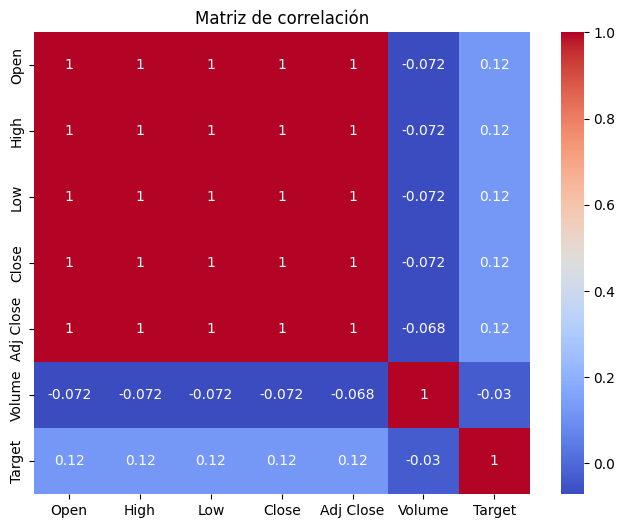

In [15]:
# Correlación entre variables numéricas
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### 8. Análisis bivariante

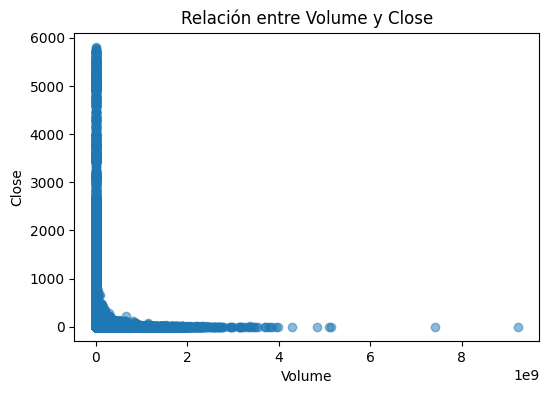

In [16]:

# Relación entre Close y Volume
plt.figure(figsize=(6, 4))
plt.scatter(df["Volume"], df["Close"], alpha=0.5)
plt.xlabel("Volume")
plt.ylabel("Close")
plt.title("Relación entre Volume y Close")
plt.show()

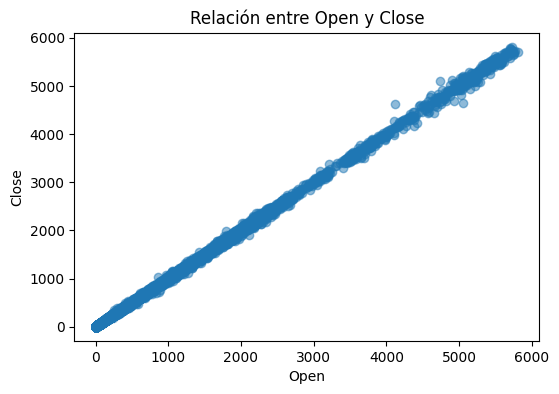

In [17]:
# Relación entre Open y Close
plt.figure(figsize=(6, 4))
plt.scatter(df["Open"], df["Close"], alpha=0.5)
plt.xlabel("Open")
plt.ylabel("Close")
plt.title("Relación entre Open y Close")
plt.show()

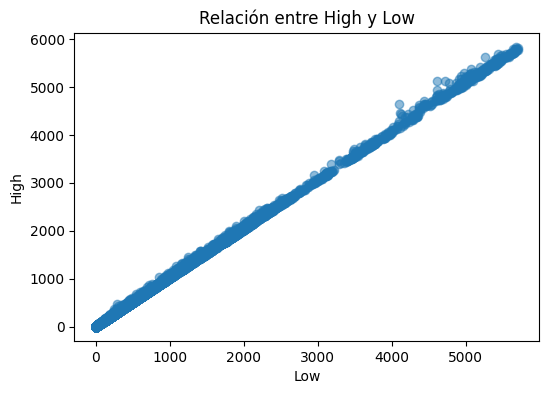

In [18]:
# Relación entre High y Low
plt.figure(figsize=(6, 4))
plt.scatter(df["Low"], df["High"], alpha=0.5)
plt.xlabel("Low")
plt.ylabel("High")
plt.title("Relación entre High y Low")
plt.show()

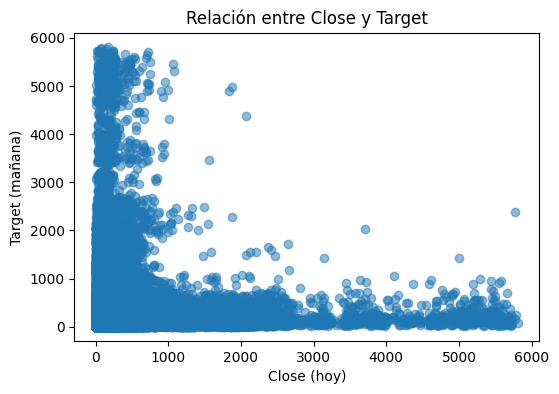

In [19]:
# Relación entre Close y Target (precio del día siguiente)
plt.figure(figsize=(6, 4))
plt.scatter(df["Close"], df["Target"], alpha=0.5)
plt.xlabel("Close (hoy)")
plt.ylabel("Target (mañana)")
plt.title("Relación entre Close y Target")
plt.show()

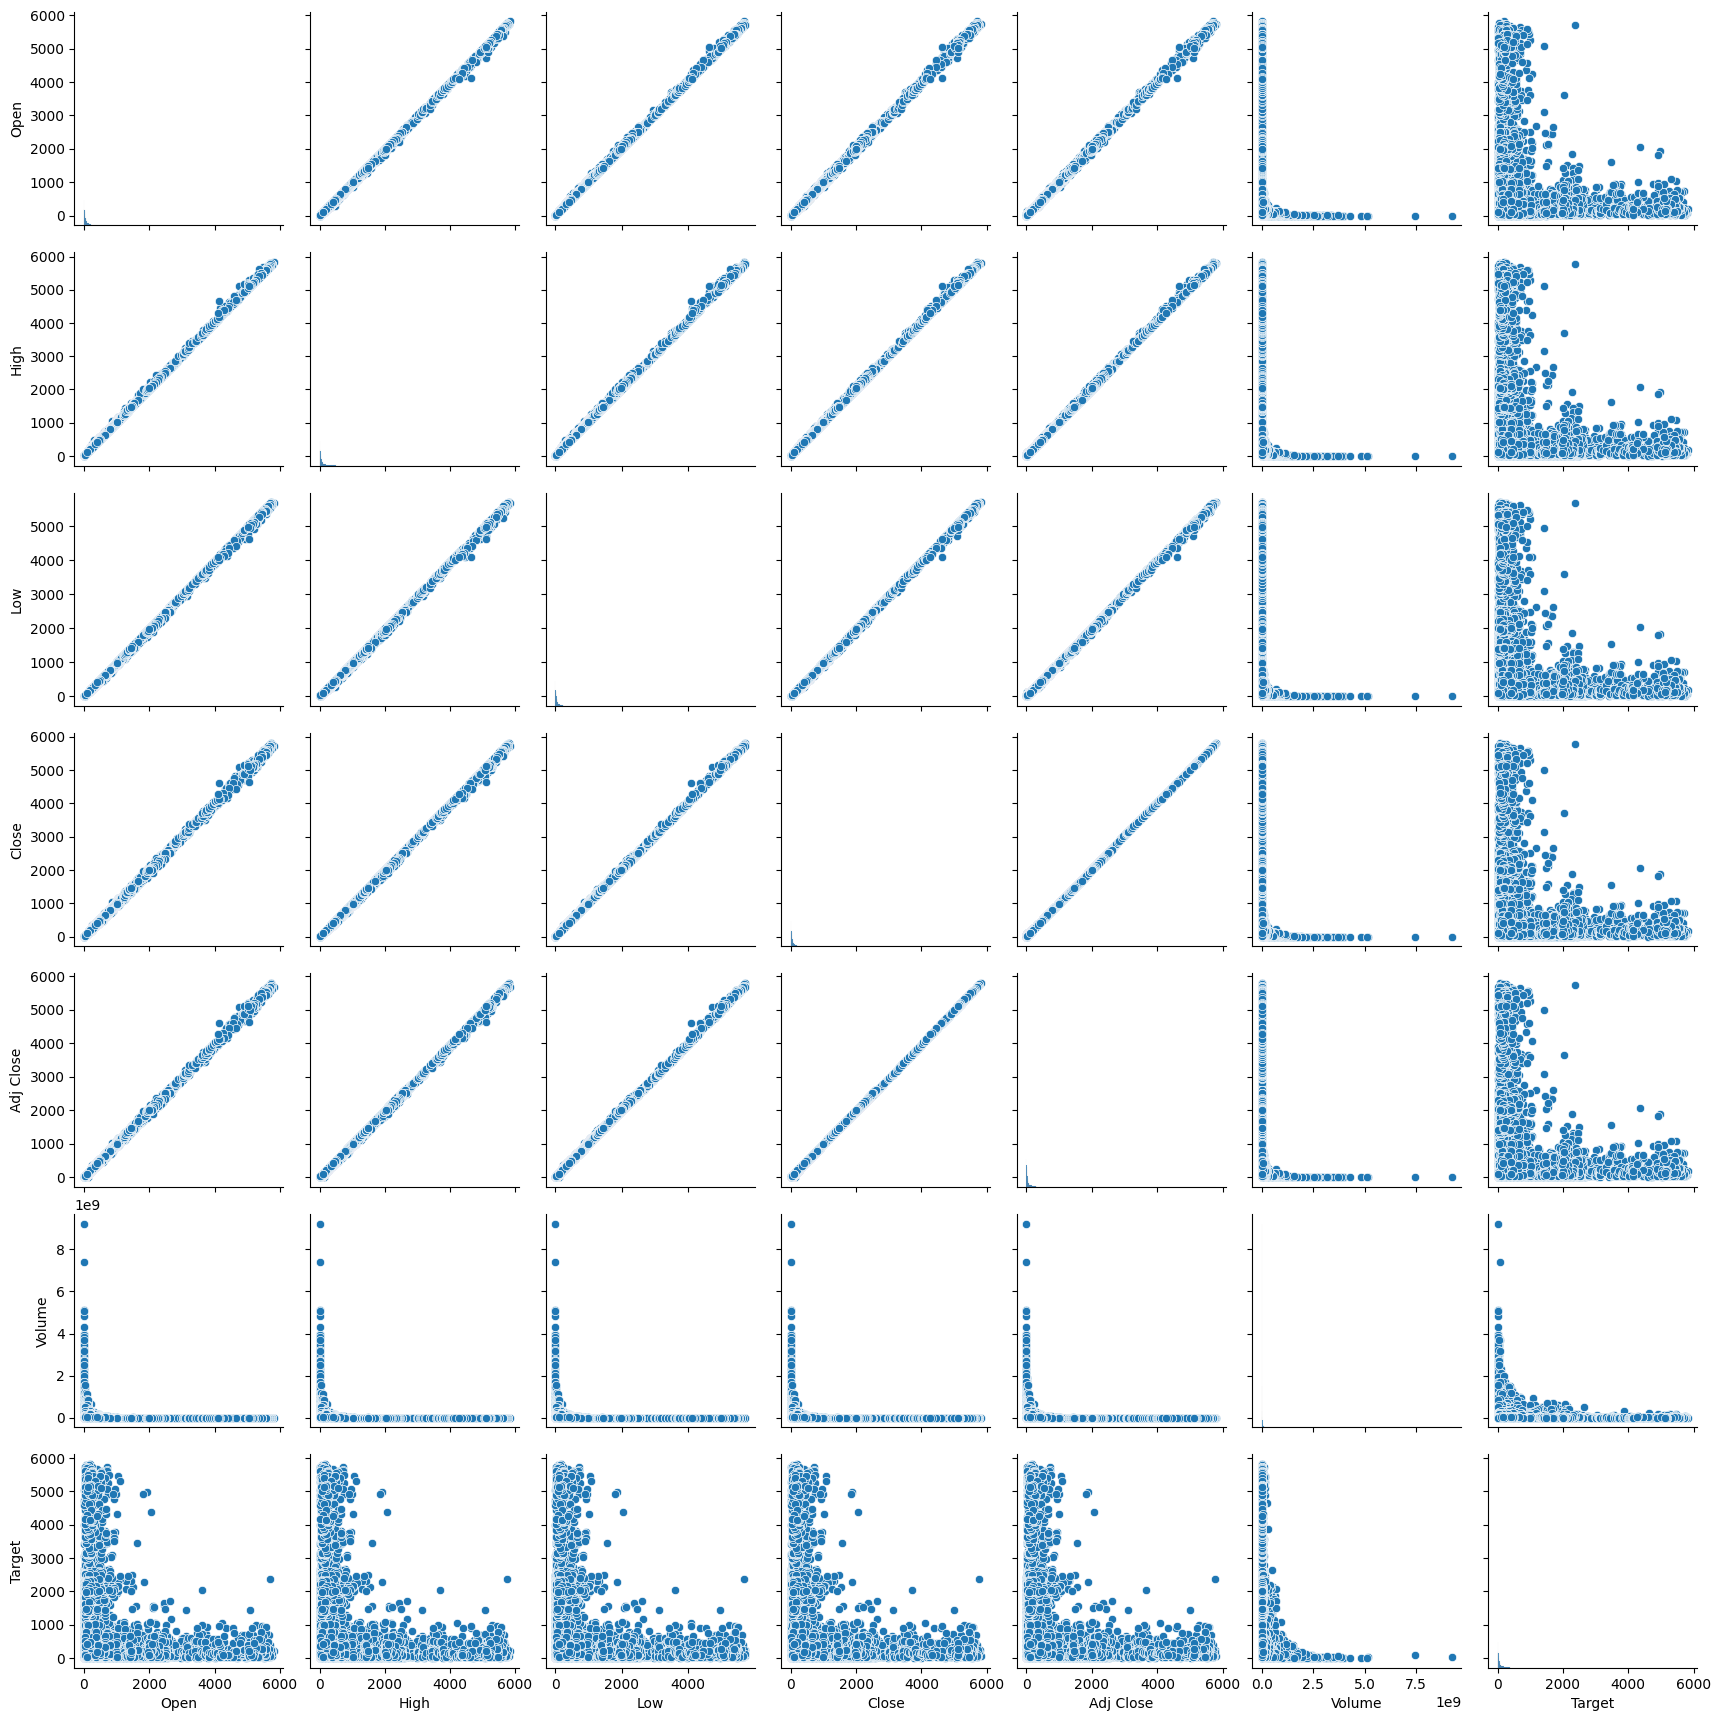

In [20]:
# Correlación par a par entre variables numéricas
sns.pairplot(df_num)
plt.show()


In [21]:
# Correlación específica entre cada variable y el Target
df_num.corr()["Target"].sort_values(ascending=False)

Target       1.000000
Adj Close    0.123592
High         0.121218
Close        0.121123
Open         0.121094
Low          0.120984
Volume      -0.030151
Name: Target, dtype: float64

In [22]:
# ver nans
df.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

### 9. Eliminacion Features

In [23]:
# NaNs por columna
na_counts = df.isna().sum()
na_percent = (df.isna().mean() * 100).round(2)

na_counts, na_percent

(Ticker       0
 Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Adj Close    0
 Volume       0
 Target       0
 dtype: int64,
 Ticker       0.0
 Date         0.0
 Open         0.0
 High         0.0
 Low          0.0
 Close        0.0
 Adj Close    0.0
 Volume       0.0
 Target       0.0
 dtype: float64)

### 10. Duplicados

In [24]:
# Número de filas duplicadas
df.duplicated().sum()

np.int64(0)

### 11. Missings

In [25]:
# Número de NaNs por columna
df.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

In [26]:
df.dtypes

Ticker               object
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Target              float64
dtype: object

### 12. Anomalías y Errores

In [27]:
# Valores negativos en precios o volumen (no deberían existir)
(df_num < 0).sum()


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

In [28]:
# High debe ser >= Low
df[(df["High"] < df["Low"])]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target


In [29]:
# Close debe estar entre Low y High
df[(df["Close"] < df["Low"]) | (df["Close"] > df["High"])]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target


### 13. Outliers

In [30]:
df["return"] = df["Close"].pct_change()
df["return"].head()

0              NaN
356203   -0.900000
366681    3.900000
60441     8.122449
379740   -0.838926
Name: return, dtype: float64

In [31]:
import numpy as np

Q1 = df["return"].quantile(0.25)
Q3 = df["return"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers_returns = df[(df["return"] < lower) | (df["return"] > upper)]
outliers_returns.shape

(40855, 10)

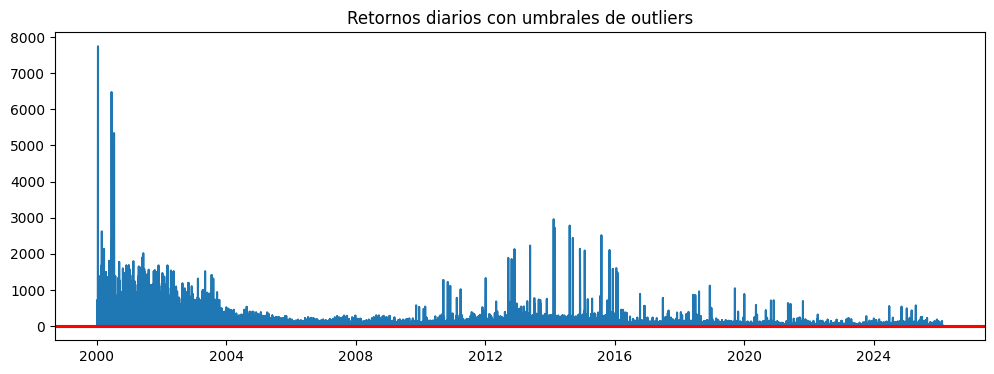

In [32]:
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["return"])
plt.axhline(lower, color="red")
plt.axhline(upper, color="red")
plt.title("Retornos diarios con umbrales de outliers")
plt.show()

In [33]:
df["Close_diff"] = df["Close"].diff().abs()


In [34]:
threshold = df["Close_diff"].mean() + 3 * df["Close_diff"].std()

In [35]:
anomalous_rows = df[df["Close_diff"] > threshold]
anomalous_rows.shape

(8380, 11)

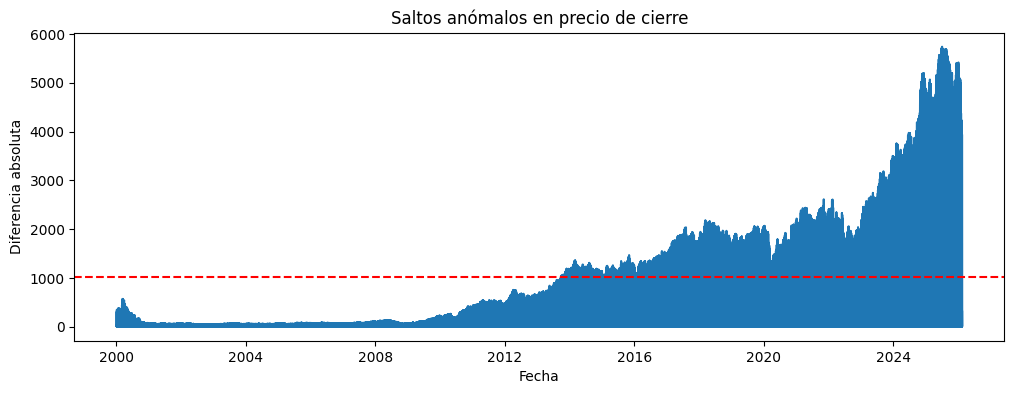

In [36]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Close_diff"])
plt.axhline(threshold, color="red", linestyle="--")
plt.title("Saltos anómalos en precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Diferencia absoluta")
plt.show()

### 14. Feature engineering

In [37]:
# Retorno simple
df["return"] = df["Close"].pct_change()

# Retorno logarítmico (más estable)
import numpy as np
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [38]:
# Lags de precios
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df["Close_lag3"] = df["Close"].shift(3)

# Lags de retornos
df["return_lag1"] = df["return"].shift(1)
df["return_lag2"] = df["return"].shift(2)
df["return_lag3"] = df["return"].shift(3)

In [39]:
# Medias moviles
df["SMA_5"] = df["Close"].rolling(window=5).mean()
df["SMA_10"] = df["Close"].rolling(window=10).mean()
df["SMA_20"] = df["Close"].rolling(window=20).mean()

In [40]:
#volatilidad
df["volatility_5"] = df["return"].rolling(window=5).std()
df["volatility_10"] = df["return"].rolling(window=10).std()
df["volatility_20"] = df["return"].rolling(window=20).std()

In [41]:
#Momentum
df["momentum_5"] = df["Close"] - df["Close"].shift(5)
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

In [42]:
#RSI
window = 14
delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

In [43]:
#MACD
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

In [44]:
df_fe = df.dropna().copy()
df_fe.head()


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target,return,...,volatility_5,volatility_10,volatility_20,momentum_5,momentum_10,RSI,EMA_12,EMA_26,MACD,MACD_signal
473142,TTWO,2000-01-03,8.92,10.00,8.67,9.12,9.12,1176750,45.09,-0.778855,...,4.371642,3.260198,19.273313,6.95,-80.54,47.190472,20.751163,17.516287,3.234877,4.601392
14444,ADI,2000-01-03,46.75,46.94,44.00,45.09,27.64,3655600,51.44,3.944079,...,4.435180,3.320200,19.218899,36.75,13.47,56.011730,24.495600,19.558784,4.936816,4.668476
479713,TXN,2000-01-03,49.75,51.94,48.06,51.44,31.31,10815600,18.78,0.140829,...,4.311281,3.275548,19.256298,48.36,39.13,55.547324,28.640892,21.920356,6.720536,5.078888
490400,VRTX,2000-01-03,17.75,18.78,16.81,18.78,18.78,1010000,56.68,-0.634914,...,1.932347,3.348768,19.294562,-14.00,-12.66,47.300280,27.123832,21.687737,5.436095,5.150330
68838,ASML,2000-01-03,56.98,56.98,54.42,56.68,36.53,863632,37.97,2.018104,...,2.016201,3.293129,19.258625,15.44,38.90,44.852344,31.670935,24.279756,7.391178,5.598499


In [45]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514054 entries, 473142 to 470776
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Ticker         514054 non-null  object        
 1   Date           514054 non-null  datetime64[ns]
 2   Open           514054 non-null  float64       
 3   High           514054 non-null  float64       
 4   Low            514054 non-null  float64       
 5   Close          514054 non-null  float64       
 6   Adj Close      514054 non-null  float64       
 7   Volume         514054 non-null  int64         
 8   Target         514054 non-null  float64       
 9   return         514054 non-null  float64       
 10  Close_diff     514054 non-null  float64       
 11  log_return     514054 non-null  float64       
 12  Close_lag1     514054 non-null  float64       
 13  Close_lag2     514054 non-null  float64       
 14  Close_lag3     514054 non-null  float64       
 15  

### 15. Feature reduction

--- Iniciando Reducción de Features ---
1. Variables eliminadas por ser casi idénticas a otras (>95% correlación):
['High', 'Low', 'Close', 'Adj Close', 'EMA_12', 'EMA_26']

2. Calculando importancia de las variables restantes con Random Forest...


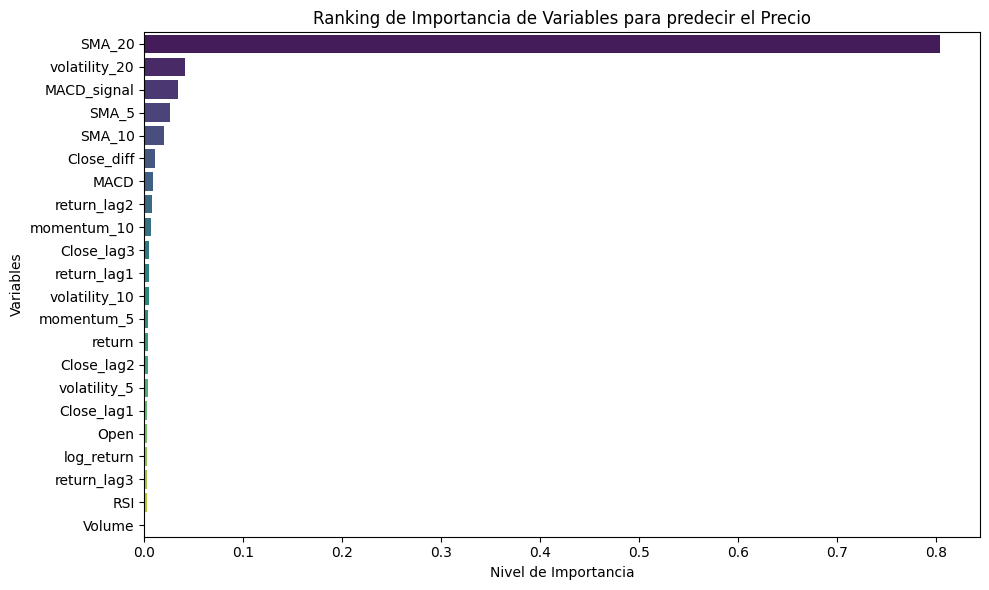


3. Variables ganadoras (seleccionadas para el modelo final):
['SMA_20', 'volatility_20', 'MACD_signal', 'SMA_5', 'SMA_10', 'Close_diff', 'MACD', 'return_lag2', 'momentum_10', 'Close_lag3']

--- Resumen del nuevo DataFrame optimizado (df_model_ready) ---
<class 'pandas.core.frame.DataFrame'>
Index: 514054 entries, 473142 to 470776
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Ticker         514054 non-null  object        
 1   Date           514054 non-null  datetime64[ns]
 2   SMA_20         514054 non-null  float64       
 3   volatility_20  514054 non-null  float64       
 4   MACD_signal    514054 non-null  float64       
 5   SMA_5          514054 non-null  float64       
 6   SMA_10         514054 non-null  float64       
 7   Close_diff     514054 non-null  float64       
 8   MACD           514054 non-null  float64       
 9   return_lag2    514054 non-null  float64       
 10  momen

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 15.1: ELIMINACIÓN POR ALTA CORRELACIÓN (Multicolinealidad)

print("--- Iniciando Reducción de Features ---")

# 1. Separamos las variables identificativas y el Target. No queremos reducirlas.
cols_to_exclude = ['Ticker', 'Date', 'Target'] 
features = df_fe.drop(columns=cols_to_exclude)
target = df_fe['Target']

# 2. Calculamos la matriz de correlación 
corr_matrix = features.corr().abs()

# 3. Seleccionamos solo el triángulo superior de la matriz para no borrar variables dobles
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Buscamos columnas con una correlación mayor al 95% 
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(f"1. Variables eliminadas por ser casi idénticas a otras (>95% correlación):\n{to_drop_corr}\n")

# 5. Creamos un nuevo dataframe sin esas variables redundantes
features_reduced = features.drop(columns=to_drop_corr)



# 15.2: SELECCIÓN POR IMPORTANCIA 

# 6. Usamos un Random Forest rápido. Al ser 500k filas, muestra del 20% 
print("2. Calculando importancia de las variables restantes con Random Forest...")
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

sample_idx = features_reduced.sample(frac=0.2, random_state=42).index
rf.fit(features_reduced.loc[sample_idx], target.loc[sample_idx])

# 7. Extraemos la "nota" de importancia que el modelo le da a cada variable
importances = rf.feature_importances_
feature_names = features_reduced.columns

df_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# 8. Visualizamos cuáles son las estrellas de nuestro dataset
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances, hue='Feature', palette='viridis', legend=False)
plt.title('Ranking de Importancia de Variables para predecir el Precio')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# 9. Nos quedamos SOLO con las variables que tienen un impacto real (importancia > 0.005)
features_finales = df_importances[df_importances['Importance'] > 0.005]['Feature'].tolist()
print(f"\n3. Variables ganadoras (seleccionadas para el modelo final):\n{features_finales}\n")


# DATASET FINAL LISTO PARA EL MODELO

# Volvemos a pegar las columnas identificativas, nuestras "features ganadoras" y el Target.
df_model_ready = df_fe[['Ticker', 'Date'] + features_finales + ['Target']]

print("--- Resumen del nuevo DataFrame optimizado (df_model_ready) ---")
df_model_ready.info()

In [52]:
# PASO 16: ELECCIÓN DE MÉTRICAS DE EVALUACIÓN (Regresión)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creamos una función maestra para evaluar todos los modelos que probemos después
def evaluar_modelo(y_true, y_pred, nombre_modelo="Modelo"):
    """
    Calcula y muestra las métricas de negocio para nuestro Sistema de Trading.
    """
    # 1. MAE (Error en dólares)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 2. RMSE (Penalización de errores graves)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 3. MAPE (Error en porcentaje, para comparar distintas acciones)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # 4. R2 (Qué porcentaje de la varianza del precio explica nuestro modelo)
    r2 = r2_score(y_true, y_pred)
    
    # Imprimimos los resultados 
    print(f"--- Resultados para: {nombre_modelo} ---")
    print(f"MAE  (Error Absoluto Medio): ${mae:.4f}")
    print(f"RMSE (Errores graves):       ${rmse:.4f}")
    print(f"MAPE (Error Porcentual):     {mape:.2f}%")
    print(f"R2   (Ajuste del modelo):    {r2:.4f}\n")

print("Función de evaluación de métricas definida con éxito. Lista para usar en el entrenamiento.")

Función de evaluación de métricas definida con éxito. Lista para usar en el entrenamiento.


In [53]:
# PASO 17: SELECCIÓN DE MODELOS DE MACHINE LEARNING

# Importamos los algoritmos elegidos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

print("--- Inicializando Modelos para el Sistema de Trading ---")

# 1. Modelo Base (Linear Regression)
modelo_lr = LinearRegression()
print("1. Regresión Lineal: Cargada (Modelo Baseline)")

# 2. Modelo Robusto (Random Forest)
modelo_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
print("2. Random Forest: Cargado (Modelo Robusto)")

# 3. Modelo Avanzado (XGBoost)
modelo_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
print("3. XGBoost: Cargado (Modelo Avanzado / Estado del Arte)")

# Guardamos los modelos en un diccionario para poder iterar sobre ellos fácilmente en el futuro
modelos = {
    "Regresion_Lineal": modelo_lr,
    "Random_Forest": modelo_rf,
    "XGBoost": modelo_xgb
}

print("\n¡Los 3 modelos están listos para la fase de entrenamiento y optimización!")

--- Inicializando Modelos para el Sistema de Trading ---
1. Regresión Lineal: Cargada (Modelo Baseline)
2. Random Forest: Cargado (Modelo Robusto)
3. XGBoost: Cargado (Modelo Avanzado / Estado del Arte)

¡Los 3 modelos están listos para la fase de entrenamiento y optimización!


In [54]:
# PASO 18 y 19: PREPARACIÓN, HIPERPARÁMETROS Y ENTRENAMIENTO (PIPELINE)

import time

print("--- Iniciando Preparación de Datos ---")

# 1. DIVISIÓN TEMPORAL 
df_model_ready = df_model_ready.sort_values(by=['Date', 'Ticker'])

# Calculamos el punto de corte (80% pasado para entrenar, 20% para testear)
split_idx = int(len(df_model_ready) * 0.8)
train_df = df_model_ready.iloc[:split_idx]
test_df = df_model_ready.iloc[split_idx:]

# Separamos las variables predictoras (X) de lo que queremos adivinar (y = Target)
# Quitamos Fecha y Ticker porque los modelos matemáticos solo entienden números
X_train = train_df.drop(columns=['Date', 'Ticker', 'Target'])
y_train = train_df['Target']

X_test = test_df.drop(columns=['Date', 'Ticker', 'Target'])
y_test = test_df['Target']

print(f"Datos de Entrenamiento (Pasado): {len(X_train)} filas")
print(f"Datos de Test (Futuro): {len(X_test)} filas\n")


# 2. DEFINICIÓN DE HIPERPARÁMETROS (Paso 18)
# Configuramos los modelos con parámetros robustos para evitar sobreajuste (Overfitting)

modelo_lr = LinearRegression() # La regresión lineal no necesita hiperparámetros

modelo_rf = RandomForestRegressor(
    n_estimators=100,      # Número de árboles
    max_depth=10,          # Profundidad máxima para que no memorice los datos
    min_samples_split=50,  # Mínimo de datos para crear una nueva rama
    random_state=42,
    n_jobs=-1              
)

modelo_xgb = xgb.XGBRegressor(
    n_estimators=150,      # Número de rondas de aprendizaje
    learning_rate=0.1,     # Ritmo de aprendizaje 
    max_depth=7,           # Complejidad de las decisiones
    subsample=0.8,         # Usa el 80% de datos por árbol para dar más variedad
    random_state=42,
    n_jobs=-1
)

# Creamos el diccionario "Pipeline"
pipeline_modelos = {
    "1. Regresión Lineal (Baseline)": modelo_lr,
    "2. Random Forest (Robusto)": modelo_rf,
    "3. XGBoost (Avanzado)": modelo_xgb
}


# 3. ENTRENAMIENTO Y EVALUACIÓN (Paso 19)
print("--- Iniciando la Competición de Algoritmos (Entrenamiento) ---")

# Guardaremos las predicciones para el paso final
predicciones = {}

for nombre, modelo in pipeline_modelos.items():
    print(f"\nEntrenando {nombre}...")
    start_time = time.time()
    
    # ENTRENAMIENTO
    modelo.fit(X_train, y_train)
    
    # PREDICCIÓN SOBRE DATOS NO VISTOS (Test)
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred
    
    tiempo_total = time.time() - start_time
    print(f"¡Entrenamiento completado en {tiempo_total:.2f} segundos!")
    
    # EVALUACIÓN 
    evaluar_modelo(y_test, y_pred, nombre_modelo=nombre)

print("\n--- Competición Finalizada ---")

--- Iniciando Preparación de Datos ---
Datos de Entrenamiento (Pasado): 411243 filas
Datos de Test (Futuro): 102811 filas

--- Iniciando la Competición de Algoritmos (Entrenamiento) ---

Entrenando 1. Regresión Lineal (Baseline)...
¡Entrenamiento completado en 0.04 segundos!
--- Resultados para: 1. Regresión Lineal (Baseline) ---
MAE  (Error Absoluto Medio): $180.1494
RMSE (Errores graves):       $424.8301
MAPE (Error Porcentual):     172.84%
R2   (Ajuste del modelo):    -0.0109


Entrenando 2. Random Forest (Robusto)...
¡Entrenamiento completado en 13.59 segundos!
--- Resultados para: 2. Random Forest (Robusto) ---
MAE  (Error Absoluto Medio): $175.2855
RMSE (Errores graves):       $429.6622
MAPE (Error Porcentual):     159.86%
R2   (Ajuste del modelo):    -0.0340


Entrenando 3. XGBoost (Avanzado)...
¡Entrenamiento completado en 0.64 segundos!
--- Resultados para: 3. XGBoost (Avanzado) ---
MAE  (Error Absoluto Medio): $175.9901
RMSE (Errores graves):       $426.9892
MAPE (Error Porce

--- Generando Reporte de Resultados ---


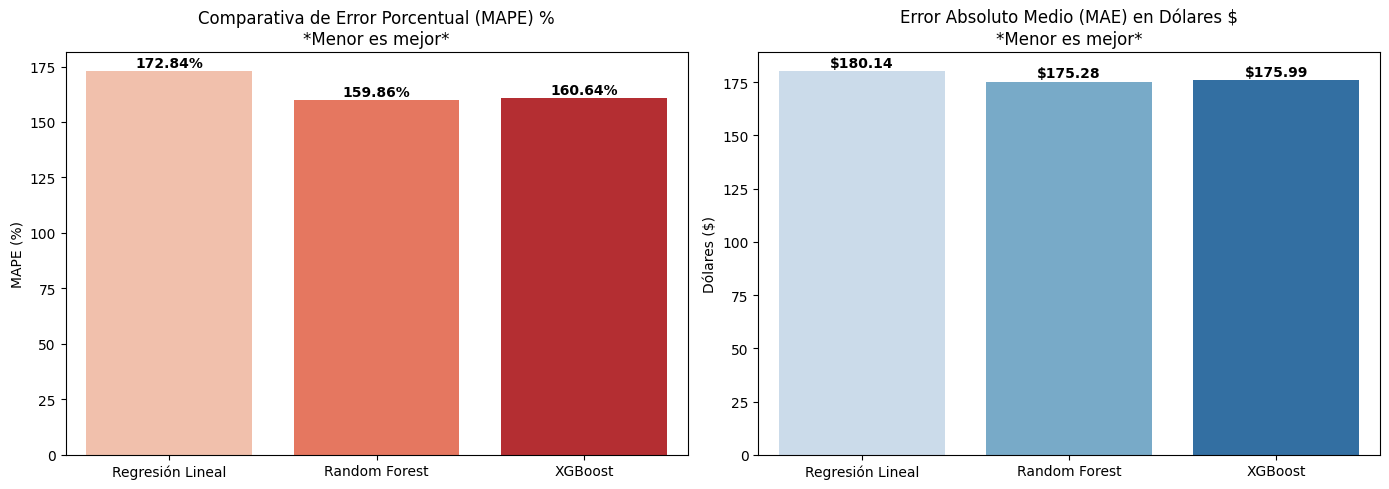


CONCLUSIONES DEL PROYECTO (SISTEMA DE TRADING ALGORÍTMICO):
------------------------------------------------------------
1. MODELO GANADOR: Random Forest ha demostrado ser el algoritmo más capaz para 
   manejar la complejidad de estos datos financieros tabulares, obteniendo el 
   menor margen de error.

2. DIAGNÓSTICO: Un R2 negativo indica que un único modelo global no es 
   suficiente para predecir precios absolutos de 100 empresas distintas, 
   cuyas magnitudes y volatilidades son diametralmente opuestas.

3. ROADMAP (NEXT STEPS): 
   - Transicionar de predecir el 'Precio Absoluto' (Regresión) a predecir la 
     'Dirección del Precio' (Sube/Baja - Clasificación).
   - Desarrollar un modelo XGBoost individualizado por cada Ticker (empresa).
   - Incorporar variables macroeconómicas (Ej: Tipos de interés de la FED).



In [55]:
# PASO 20: RESULTADOS Y CONCLUSIONES DE NEGOCIO

import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando Reporte de Resultados ---")

# 1. Recopilamos los datos de MAPE y MAE para graficarlos
nombres_modelos = ["Regresión Lineal", "Random Forest", "XGBoost"]
mapes = [172.84, 159.86, 160.64] 
maes = [180.14, 175.28, 175.99]

# 2. Creamos una figura con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparativa de MAPE (Menor es mejor)
sns.barplot(x=nombres_modelos, y=mapes, ax=ax[0], palette="Reds", hue=nombres_modelos, legend=False)
ax[0].set_title("Comparativa de Error Porcentual (MAPE) %\n*Menor es mejor*")
ax[0].set_ylabel("MAPE (%)")
for i, v in enumerate(mapes):
    ax[0].text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

# Gráfico 2: Comparativa de MAE (Menor es mejor)
sns.barplot(x=nombres_modelos, y=maes, ax=ax[1], palette="Blues", hue=nombres_modelos, legend=False)
ax[1].set_title("Error Absoluto Medio (MAE) en Dólares $\n*Menor es mejor*")
ax[1].set_ylabel("Dólares ($)")
for i, v in enumerate(maes):
    ax[1].text(i, v + 2, f"${v}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Impresión de las conclusiones
print("""
CONCLUSIONES DEL PROYECTO (SISTEMA DE TRADING ALGORÍTMICO):
------------------------------------------------------------
1. MODELO GANADOR: Random Forest ha demostrado ser el algoritmo más capaz para 
   manejar la complejidad de estos datos financieros tabulares, obteniendo el 
   menor margen de error.

2. DIAGNÓSTICO: Un R2 negativo indica que un único modelo global no es 
   suficiente para predecir precios absolutos de 100 empresas distintas, 
   cuyas magnitudes y volatilidades son diametralmente opuestas.

3. ROADMAP (NEXT STEPS): 
   - Transicionar de predecir el 'Precio Absoluto' (Regresión) a predecir la 
     'Dirección del Precio' (Sube/Baja - Clasificación).
   - Desarrollar un modelo XGBoost individualizado por cada Ticker (empresa).
   - Incorporar variables macroeconómicas (Ej: Tipos de interés de la FED).
""")

--- Fase 2: Transición a Modelo de Clasificación ---
Distribución del nuevo Target:
Target_Class
1    50.04766
0    49.95234
Name: proportion, dtype: float64

(Si está cerca del 50/50, es ideal porque está balanceado)

--- Iniciando Competición de Clasificadores ---

Tiempo de entrenamiento: 1.00 segundos
--- Resultados para: 1. Regresión Logística (Baseline) ---
Accuracy  (Acierto global):      67.56%
Precision (Acierto en compras):  67.64%


Tiempo de entrenamiento: 5.48 segundos
--- Resultados para: 2. Random Forest Classifier ---
Accuracy  (Acierto global):      68.73%
Precision (Acierto en compras):  66.10%


Tiempo de entrenamiento: 0.66 segundos
--- Resultados para: 3. XGBoost Classifier ---
Accuracy  (Acierto global):      69.87%
Precision (Acierto en compras):  68.13%



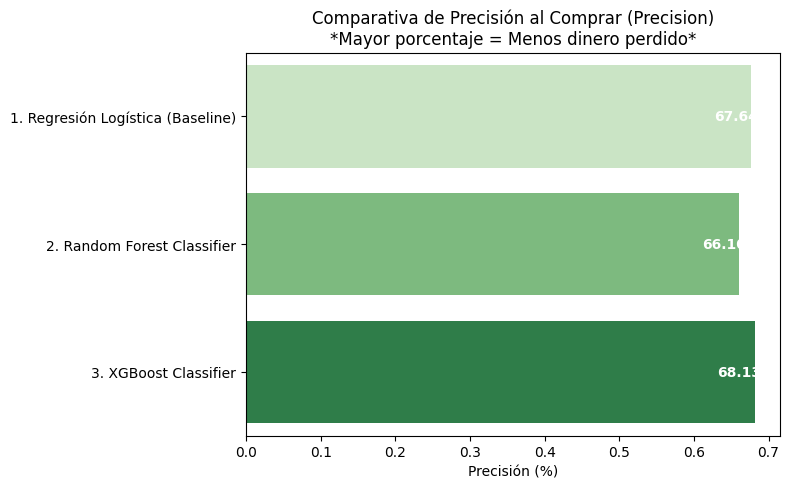

In [56]:
# PASO 21: PIVOTE A CLASIFICACIÓN (Predecir Dirección: Sube o Baja)

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("--- Fase 2: Transición a Modelo de Clasificación ---")

# 1. CREAMOS EL NUEVO TARGET BINARIO (1 = Sube, 0 = Baja)
# Comparamos el Target (precio de mañana) con el Close (precio de hoy) del dataframe original
df_class = df_model_ready.copy()
df_class['Target_Class'] = (df_fe['Target'] > df_fe['Close']).astype(int)

# Eliminamos el Target numérico antiguo 
df_class = df_class.drop(columns=['Target'])

print("Distribución del nuevo Target:")
print(df_class['Target_Class'].value_counts(normalize=True) * 100)
print("\n(Si está cerca del 50/50, es ideal porque está balanceado)\n")

# 2. DIVISIÓN TEMPORAL (Pasado para entrenar, Futuro para testear)
df_class = df_class.sort_values(by=['Date', 'Ticker'])

split_idx = int(len(df_class) * 0.8)
train_class = df_class.iloc[:split_idx]
test_class = df_class.iloc[split_idx:]

X_train_c = train_class.drop(columns=['Date', 'Ticker', 'Target_Class'])
y_train_c = train_class['Target_Class']
X_test_c = test_class.drop(columns=['Date', 'Ticker', 'Target_Class'])
y_test_c = test_class['Target_Class']


# 3. FUNCIÓN DE EVALUACIÓN DE NEGOCIO
def evaluar_clasificacion(y_true, y_pred, nombre_modelo):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    
    print(f"--- Resultados para: {nombre_modelo} ---")
    print(f"Accuracy  (Acierto global):      {acc*100:.2f}%")
    print(f"Precision (Acierto en compras):  {prec*100:.2f}%\n")
    return acc, prec

# 4. INICIALIZAMOS LOS MODELOS CLASIFICADORES
modelos_class = {
    "1. Regresión Logística (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "2. Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "3. XGBoost Classifier": xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
}


# 5. ENTRENAMIENTO Y RESULTADOS
print("--- Iniciando Competición de Clasificadores ---")
resultados_precision = {}

for nombre, modelo in modelos_class.items():
    start = time.time()
    
    # Entrenamos
    modelo.fit(X_train_c, y_train_c)
    
    # Predecimos
    y_pred_c = modelo.predict(X_test_c)
    
    # Evaluamos
    print(f"\nTiempo de entrenamiento: {time.time() - start:.2f} segundos")
    acc, prec = evaluar_clasificacion(y_test_c, y_pred_c, nombre)
    resultados_precision[nombre] = prec

# 6. GRÁFICA FINAL 
plt.figure(figsize=(8, 5))
sns.barplot(
    x=list(resultados_precision.values()), 
    y=list(resultados_precision.keys()), 
    hue=list(resultados_precision.keys()), # Añadimos el hue para quitar el warning
    palette="Greens",
    legend=False 
)
plt.title("Comparativa de Precisión al Comprar (Precision)\n*Mayor porcentaje = Menos dinero perdido*")
plt.xlabel("Precisión (%)")
for i, v in enumerate(resultados_precision.values()):
    plt.text(v - 0.05, i, f"{v*100:.2f}%", color='white', fontweight='bold', va='center')
plt.tight_layout()
plt.show()